In [66]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

def check_condition(condition, x):
    if isinstance(condition, str):
        # Vérifier si la condition commence par '<'
        if condition.startswith("<"):
            limit = int(condition[1:])  # Extraire la valeur après "<"
            return x < limit  # Retourne True si x est inférieur à la limite
        # Vérifier si la condition commence par '>'
        elif condition.startswith(">"):
            limit = int(condition[1:])  # Extraire la valeur après ">"
            return x > limit  # Retourne True si x est supérieur à la limite
        # Vérifier si la condition est de la forme "[min, max]"
        elif condition[0] == "[" and condition[-1] == "]":
            bounds = condition[1:-1].split(",")  # Séparer par la virgule
            lower = int(bounds[0].strip())  # Extraire et parser le premier nombre
            upper = int(bounds[1].strip())  # Extraire et parser le deuxième nombre
            return lower <= x <= upper  # Retourne True si x est dans l'intervalle
        else:
            raise ValueError("Format de chaîne invalide")
    elif isinstance(condition, (int, float)):  # Si la condition est un int ou float
        return x == condition  # Comparer directement x avec la condition
    else:
        raise ValueError("Condition doit être une chaîne de caractères ou un nombre (int ou float)")


def extract_triples(date, nom, mup=None, T=None, Taille=None):
    triples = {}  # Utiliser un dictionnaire pour stocker les résultats
    
    # Parcourir les fichiers dans le répertoire spécifié par 'date'
    for filename in os.listdir(date):
        # Vérifier si le nom du fichier correspond à un format attendu
        match = re.match(rf"{re.escape(nom)}_([-]?\d+\.\d+)_([-]?\d+\.\d+)_([-]?\d+\.\d+)\.npz", filename)
        if match:
            file_mup = float(match.group(1))    # Extraire mup et convertir en float
            file_T = float(match.group(2))      # Extraire T et convertir en float
            file_Taille = float(match.group(3)) # Extraire Taille et convertir en float                
            # Vérifier si les valeurs correspondent aux critères spécifiés
            if (mup is None or check_condition(mup, file_mup)) and \
               (T is None or check_condition(T, file_T)) and \
               (Taille is None or check_condition(Taille, file_Taille)):
                triples[(file_mup, file_T, file_Taille)] = 1

    return triples

def extract_triples(date, nom, params):
    triples = {}  # Utiliser un dictionnaire pour stocker les résultats

    # Parcourir les fichiers dans le répertoire spécifié par 'date'
    for filename in os.listdir(date):
        # Créer l'expression régulière pour vérifier le format du nom de fichier
        pattern = re.escape(nom)
        for param in params:
            pattern += "_([-]?\d+\.\d+)"  # Ajouter une partie pour chaque paramètre
        pattern += r"\.npz"  # Extension .npz

        # Vérifier si le fichier correspond à l'expression régulière
        match = re.match(pattern, filename)
        if match:
            condition = True
            tuple_values = []  # Liste pour stocker les paramètres extraits
            for i, param in enumerate(params):
                param_value = float(match.group(i+1))  # Convertir en float
                # Vérifier la condition
                condition = condition and (param is None or check_condition(param, param_value))
                if not condition:
                    break
                else:
                    tuple_values.append(param_value)
            
            # Si toutes les conditions sont satisfaites, ajouter le triplet au dictionnaire
            if condition:
                triples[tuple(tuple_values)] = 1  # Ajouter le tuple en tant que clé

    return triples


def corresp(dossier ,  nom , triple , exp = '.npz'):
    # Demander à l'utilisateur de saisir une série de lettres
    #entree = input("Entrez une série de lettres : ").lower()
    index_last_underscore = nom.rfind('_')
    #mu , T , Taille = triple

    #entree = f"{nom}_{mu:.3f}_{T:.3f}_{Taille:.3f}.npz"
    entree = f"{nom}"
    #entree = f"rho_{nom[:index_last_underscore]}_discr_moy_{nom[index_last_underscore+1:]}_{mu:.3f}_{T:.3f}"
    print (entree)
    
     # Lister les fichiers .mat dans le répertoire spécifié
    fichiers = [f for f in os.listdir(dossier) if (f.endswith(exp) and entree.lower() in f.lower()) ]
    #fichiers = [f for f in os.listdir(dossier) if (f.endswith(exp) and entree in f) ]


    if not fichiers:
        print(f"Aucun fichier {exp} trouvé dans le répertoire.")
        return
    
    if fichiers:
        print("Les éléments qui correspondent à votre entrée sont :")
        for item in fichiers:
            print(item)
    else:
        print(f"Aucune correspondance trouvée pour '{entree}'.")

def Listes_param(date, nom, params):
    # Extraction des triples via la fonction extract_triples
    triples = extract_triples(date, nom, params)
    
    # Liste des clés de triples
    liste_triples = list(triples.keys())
    
    # Dictionnaire pour stocker les listes de chaque paramètre
    liste_param_dict = {i: [] for i in range(len(params))}

    # Parcours de chaque triple pour remplir les listes de paramètres
    for tuple in liste_triples:
        for i, param in enumerate(params):
            if tuple[i] not in liste_param_dict[i]:
                liste_param_dict[i].append(tuple[i])

    # Récupérer les listes sous forme de liste de listes
    Listes = [sorted(liste_param_dict[i]) for i in range(len(params))]

    return Listes
    

<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\d'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_14292/562473295.py:57: SyntaxWarning: invalid escape sequence '\d'
  pattern += "_([-]?\d+\.\d+)"  # Ajouter une partie pour chaque paramètre


In [80]:
date = '2025-08-29'
nom = "inv-A1"

mu = 27.137 #None
T = None
Taille = None
theta_max =  None
npts = None



params = [mu, T, Taille,theta_max , npts]

# Extraction des triples possibles
triples = extract_triples(date, nom, params)
print("Triples key possibles:", triples.keys())

#triple = list(triples.keys())[0]

corresp(date ,  nom  , triples , exp = '.npz')

Triples key possibles: dict_keys([])
inv-A1
Les éléments qui correspondent à votre entrée sont :
inv-A1_w_mu96.854_T3.981_Taille100.000__100.000_19.862_300.000.npz
inv-A1_w_mu52.710_T112.202_Taille100.000__100.000_34.618_300.000.npz
inv-A1_w_mu49.824_T63.096_Taille100.000__100.000_28.832_300.000.npz
inv-A1_w_mu661.529_T10000.000_Taille100.000__100.000_333.740_300.000.npz
inv-A1_w_mu38.475_T891.251_Taille100.000__100.000_93.563_300.000.npz
inv-A1_w_mu211.875_T1995.262_Taille100.000__100.000_148.417_300.000.npz
inv-A1_w_mu11.517_T1412.538_Taille100.000__100.000_123.287_300.000.npz
inv-A1_w_mu97.654_T63.096_Taille100.000__100.000_31.507_300.000.npz
inv-A1_w_mu-494.459_T10000.000_Taille100.000__100.000_331.269_300.000.npz
inv-A1_w_mu96.914_T15.849_Taille100.000__100.000_21.834_300.000.npz
inv-A1_w_mu123.087_T501.187_Taille100.000__100.000_74.050_300.000.npz
inv-A1_w_mu50.746_T79.433_Taille100.000__100.000_31.146_300.000.npz
inv-A1_w_mu26.971_T1122.018_Taille100.000__100.000_108.425_300.000

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmap_with_cuts(A, x ,  cut_row_index=None, cut_column_index=None):
    """
    Affiche une heatmap de la matrice A avec des coupes dynamiques en ligne et colonne,
    ainsi que des diagonales et antidiagonales mises en évidence.
    
    Paramètres :
        - A : np.array, la matrice à afficher.
        - cut_row_index : int, indice de la ligne à couper (par défaut au milieu).
        - cut_column_index : int, indice de la colonne à couper (par défaut à 90).
    """
    # Normalisation (similaire à `normalisation = 0.5` en Julia)
    normalisation = A.shape[0]/(3* np.max(np.abs(A) ))*0.5 

    if cut_row_index is None:
        cut_row_index = A.shape[0] // 2  # Coupe au milieu si non spécifié
    if cut_column_index is None:
        cut_column_index = A.shape[1] // 2  # Coupe au milieu si non spécifié

    # Création de la heatmap
    plt.figure(figsize=(10, 10))
    plt.imshow(A, cmap='inferno', interpolation='nearest', origin='lower')
    plt.title(r"Heatmap of $\mathcal{B}$" , fontsize=20)
    plt.xlabel(r"$\theta ~(\mu m/ms)$" , fontsize=20)
    plt.ylabel(r"$\theta' ~(\mu m/ms)$" , fontsize=20)
    plt.colorbar()

    # Coupe horizontale
    plt.plot(A[cut_row_index, :] * normalisation + cut_row_index, label="Cut row", color='white', linewidth=2)
    plt.plot(np.ones(A.shape[0]) * cut_row_index, color='white', linestyle=':', linewidth=0.1)

    # Coupe verticale
    plt.plot(A[:, cut_column_index]* normalisation + cut_column_index , np.arange(0, A.shape[0]),  label="Cut column", color='white', linewidth=2)
    plt.plot(np.ones(A.shape[0]) * cut_column_index, np.arange(0, A.shape[0]),  color='white', linestyle=':', linewidth=0.1)

    # Fonction de rotation autour du point (x0, y0)
    def rot_x(x, y, x0, y0, theta):
        return x0 + (x - x0) * np.cos(theta) / np.abs(np.cos(theta)) - (y - y0) * np.sin(theta) / np.abs(np.cos(theta))

    def rot_y(x, y, x0, y0, theta):
        return y0 + (x - x0) * np.sin(theta) / np.abs(np.sin(theta)) + (y - y0) * np.cos(theta) / np.abs(np.sin(theta))

    # Rotation de la diagonale
    theta = np.pi / 4  # 45° en radians
    rotated_x = [rot_x(i, A[i, i] * normalisation, 0, 0, theta) for i in range(A.shape[0])]
    rotated_y = [rot_y(i, A[i, i] * normalisation, 0, 0, theta) for i in range(A.shape[0])]
    plt.plot(rotated_x, rotated_y, label="Diagonal", color='white', linewidth=2)

    rotated_x = [rot_x(i, 0, 0, 0, theta) for i in range(A.shape[0])]
    rotated_y = [rot_y(i, 0, 0, 0, theta) for i in range(A.shape[1])]
    plt.plot(rotated_x, rotated_y, color='white', linestyle=':', linewidth=0.1)

    # Rotation de l'antidiagonale
    theta = -np.pi / 4  # 135° en radians
    rotated_x = [rot_x(i, A[i, A.shape[1] - i - 1] * normalisation, A.shape[0]-1, 0, theta) for i in range(A.shape[0])]
    rotated_y = [rot_y(i, A[i, A.shape[1] - i - 1] * normalisation, A.shape[1]-1, 0, theta) for i in range(A.shape[0])]
    plt.plot(rotated_x, rotated_y, label="Antidiagonal", color='white', linewidth=2)

    # Lignes en pointillés pour l'antidiagonale
    rotated_x = [rot_x(i, 0, A.shape[0]-1, 0, theta) for i in range(A.shape[0])]
    rotated_y = [rot_y(i, 0, A.shape[1]-1, 0, theta) for i in range(A.shape[1])]
    plt.plot(rotated_x, rotated_y, color='white', linestyle=':', linewidth=0.1)
    
    #plt.xticks(np.arange(0, A.shape[0], 1), labels=x)
    plt.xticks([0 , A.shape[0]-1], labels=[format(x[0], '.2f'), format(x[-1], '.2f')]  , fontsize=20)
    plt.yticks([0 , A.shape[0]-1], labels=[format(x[0], '.2f'), format(x[-1], '.2f')] , fontsize=20)
    
    plt.xlim(0, A.shape[0])
    plt.ylim(0, A.shape[0])
    # Affichage du graphique
    #plt.legend( fontsize=20)
    plt.savefig("fluctu.png")
    plt.show()


In [35]:
date = '2025-08-29'

nom = "Reg"
mu = 24.746#None 
T =  None
Taille = None
theta_max =  None
npts = None
 

params = [mu, T, Taille,theta_max , npts]

# Extraction des triples possibles
triples = extract_triples(date, nom, params)
print("Triples key possibles:", triples.keys())

triple = list(triples.keys())[0]
mu , T , Taille , theta_max , npts = triple

Listes = Listes_param(date, nom, params)

for liste in Listes:
    print(liste)

#def plot_compare(Listes , current_index = 0):
#    if current_index == len(Listes) :
#        
#        non = "inv-A"
#        
#        file = f"{date}/{nom}"
#        for i in range(len(Listes)):
#            file += f"_{globals()[f"param_{i}"]:.3f}"
#        file +=  ".npz"
#        A = np.load(file)
#
#        file = f"{date}/{nom}"
#        for i in range(3 , len(Listes)):
#            file += f"_{globals()[f'param_{i}']:.3f}"
#        file += ".npz"
#        theta_discr = np.load(file)
#
#        label = f"$\theta_{{max}}$ = {globals()[f"param_{3}"]:.3f} , $\#$ = {globals()[f"param_{4}"]:.3f} "
#        plt.plot(theta_discr , [ A[i, i] for i in range(A.shape[1]) ] , label= label) 
#
#    for globals()[f"h_{current_index}"] , globals()[f"param_{current_index}"] in enumerate(Listes[current_index]):
#        plot_compare(Listes , current_index + 1)
        
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
from scipy.linalg import norm

def print_norme_remativ(A, B):
    print(f"Norme Frobenius : {norm(A-B, 'fro') / norm(A, 'fro')}")
    print(f"Norme L1 : {norm(A-B, 1) / norm(A, 1)}")
    #print(f"Norme L2 : {norm(A-B, 2) / norm(A, 2)}")
    print(f"Norme de l'infini : {norm(A-B, np.inf) / norm(A, np.inf)}")


def plot_compare(Listes, current_index=0, params=None, date=''):
    if params is None:
        params = {}

    # Base case: when we've processed all the recursive levels
    if current_index == len(Listes):
        # Construct file names based on the parameters and current state

        def generate_filename(nom):
            """
            Génère un nom de fichier basé sur le paramètre nom.
            
            :param nom: str, peut être "inv-A", "inv-A-approx" ou "theta_discr"
            :param date: str, date utilisée comme préfixe
            :param Listes: list, liste des paramètres
            :param params: dict, dictionnaire contenant les valeurs des paramètres
            :return: str, chemin du fichier généré
            """
            if nom != "theta_discr":
                filename = f"{date}/{nom}"
                for i in range(len(Listes)):
                    filename += f"_{params.get(f'param_{i}', 0):.3f}"
                filename += ".npz"
            
            elif nom == "theta_discr":
                filename = f"{date}/theta_discr"
                for i in range(3, len(Listes)):
                    filename += f"_{params.get(f'param_{i}', 0):.3f}"
                filename += ".npz"
            
            else:
                raise ValueError("Nom non reconnu. Utilisez 'inv-A', 'inv-A-approx' ou 'theta_discr'.")
            
            return filename

        try:
            # Load the data from the files
            #inv_A1 = np.load(generate_filename("inv-A1"))
            A1 = np.load(generate_filename("A1"))
            A2 = np.load(generate_filename("A2"))
            A3 = np.load(generate_filename("A3"))
            inv_A = np.load(generate_filename("inv-A"))
            #A_approx = np.load(generate_filename("inv-A-approx"))
            #A_approx_ordre = np.load(generate_filename("inv-A-approx-ordre"))
            theta_discr = np.load(generate_filename("theta_discr"))
            #F = np.load(generate_filename("F"))
            Reg = np.load(generate_filename("Reg"))

            plot_heatmap_with_cuts(Reg, theta_discr ,  cut_row_index=300, cut_column_index=500)

            # Plotting the diagonal of A against theta_discr
            label = f"$\\theta_{{max}}$ = {params.get('param_3', 0):.3f} , $\#$ = {params.get('param_4', 0):.3f} "
            label = f"$\mu$ = {params.get('param_0', 0):.3f} $nK$, $T$ = {params.get('param_1', 0):.3f} $nK$, $\ell$ = {params.get('param_2', 0):.3f} $\mu m$, $\\theta_{{max}}$ = {params.get('param_3', 0):.3f} $\\mu m/ms$, $\#$ = {params.get('param_4', 0):.3f} "
            #plt.plot(theta_discr, [inv_A[i, i] for i in range(inv_A.shape[1])], label=label)

            #label = f"inv $\\theta_{{max}}$ = {params.get('param_3', 0):.3f} , $\#$ = {params.get('param_4', 0):.3f} "
            #plt.plot(theta_discr, [A_approx[i, i] for i in range(A_approx.shape[1])], label=label)
            #plt.plot(theta_discr, [A_approx[i, i] for i in range(A_approx.shape[1])], label=label)

            #plot_heatmap_with_cuts(F)

            print(label)
            print(" F et  (inv_A - inv_A1) ")
            plot_heatmap_with_cuts(F - (inv_A - inv_A1))
            print_norme_remativ(F ,  (inv_A - inv_A1)) 
            
            #plot_heatmap_with_cuts(F -  (-(inv_A1@(A2+A3))@inv_A1))
            #print_norme_remativ(F, -(inv_A1@(A2+A3))@inv_A1)

            plot_heatmap_with_cuts(F -  (A_approx_ordre-inv_A1))
            print_norme_remativ(F, A_approx_ordre-inv_A1)

            #plot_heatmap_with_cuts(A_approx -  A_approx_ordre)
            #print_norme_remativ(A_approx, A_approx_ordre)
            
            #plot_heatmap_with_cuts(inv_A1)
            #plot_heatmap_with_cuts(F)
           # plot_heatmap_with_cuts(F-(- (inv_A1*(A2+A3))*inv_A1))

            
                  
            print("ordre '1' , 10 ")
            print_norme_remativ(A_approx, A_approx_ordre)
            print("ordre '1' , 1 ")
            print_norme_remativ(A_approx, inv_A1 -(inv_A1@(A2+A3))@inv_A1)
            print("ordre '0' , 0 ")
            print_norme_remativ(inv_A1, inv_A1)
            print(" inv A   ordre ")
            print_norme_remativ(inv_A, A_approx_ordre)

        except FileNotFoundError as e:
            print(f"Erreur : fichier introuvable - {e}")
        except ValueError as e:
            print(f"Erreur de chargement des données : {e}")
        except Exception as e:
            print(f"Une erreur inattendue s'est produite : {e}")

        return  # Exit recursion once we've done all the plotting

    # Recursive case: iterate over the values in Listes[current_index]
    for h_value in Listes[current_index]:
        params[f'param_{current_index}'] = h_value  # Update parameter dictionary
        plot_compare(Listes, current_index + 1, params, date)

# Example usage:
# plot_compare(Listes, current_index=0, params={'param_0': 1.0, 'param_1': 2.0}, date='2025-02-24', nom='experiment')



plot_compare(Listes, current_index=0, params=None, date=date)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

24.74574496

<>:112: SyntaxWarning: invalid escape sequence '\#'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\e'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\#'
<>:112: SyntaxWarning: invalid escape sequence '\#'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\e'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\#'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_49491/3497930260.py:112: SyntaxWarning: invalid escape sequence '\#'
  label = f"$\\theta_{{max}}$ = {params.get('param_3', 0):.3f} , $\#$ = {params.get('param_4', 0):.3f} "
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_49491/3497930260.py:113: SyntaxWarning: invalid escape sequence '\m'
  label = f"$\mu$ = {params.get('param_0', 0):.3f} $nK$, $T$ = {params.get('param_1', 0):.3f} $nK$, $\ell$ = {params.ge

NameError: name 'extract_triples' is not defined

In [88]:
theta_discr = load_npz_data("./2025-08-29/theta_discr_w_32.304_300.000.npz")
nu_discr= load_npz_data("./2025-08-29/nu_discr_w_32.304_300.000.npz")
rho_s = load_npz_data("./2025-08-29/rho_s_discr_w_32.304_300.000.npz")
Reg = load_npz_data("./2025-08-29/Reg_w_mu51.329_T89.125_Taille100.000__100.000_32.304_300.000.npz")

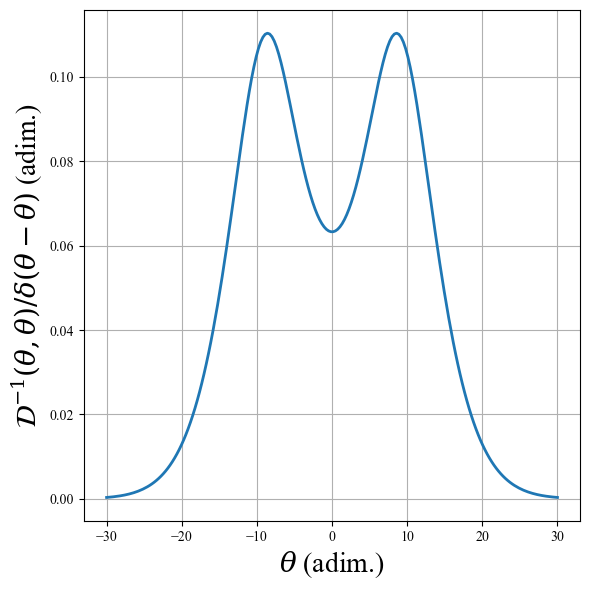

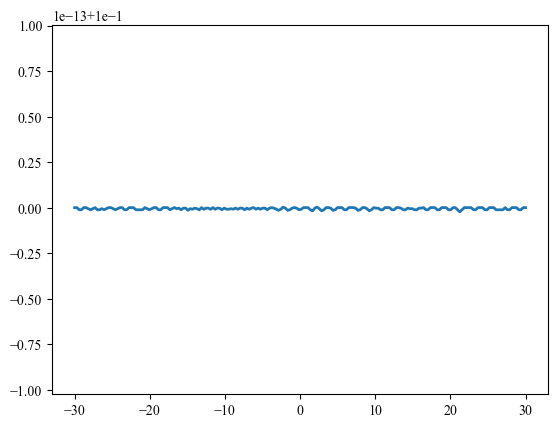

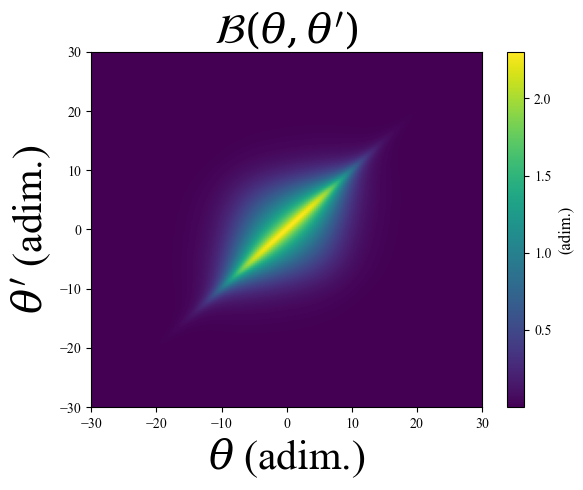

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Chargement des données
theta_discr = np.load("./2025-08-29/theta_discr_w_32.304_300.000.npz")#["arr_0"]
nu_discr= np.load("./2025-08-29/nu_discr_w_32.304_300.000.npz")#["arr_0"]
rho_s = np.load("./2025-08-29/rho_s_discr_w_32.304_300.000.npz")#["arr_0"]
Reg = np.load("./2025-08-29/Reg_w_mu51.329_T89.125_Taille100.000__100.000_32.304_300.000.npz")#["arr_0"]
Irreg = np.load("./2025-08-29/Irreg_w_mu51.329_T89.125_Taille100.000__100.000_32.304_300.000.npz")#["arr_0"]

theta_discr = np.load("./2025-11-03/theta_discr_w_10.000_200.000.npz")#["arr_0"]
nu_discr= np.load("./2025-11-03/nu_discr_w_10.000_200.000.npz")#["arr_0"]
rho_s = np.load("./2025-11-03/rho_s_discr_w_10.000_200.000.npz")#["arr_0"]
Reg = np.load("./2025-11-03/Reg_w_10.000_10.000_200.000.npz")#["arr_0"]
Irreg = np.load("./2025-11-03/Irreg_w_10.000_10.000_200.000.npz")#["arr_0"]

theta_discr = np.load("./2025-11-17/theta_discr_w_30.000_200.000.npz")
nu_discr= np.load("./2025-11-17/nu_discr_w_30.000_200.000.npz")
rho_s = np.load("./2025-11-17/rho_s_discr_w_30.000_200.000.npz")
Reg = np.load("./2025-11-17/Reg_w_10.000_30.000_200.000.npz")
Irreg = np.load("./2025-11-17/Irreg_w_10.000_30.000_200.000.npz")


# 1. Tracer rho_s^2 * (1 - rho_s) en fonction de theta_discr
f_vals = rho_s * nu_discr * (1 - nu_discr)

plt.figure(figsize=(6,6))
plt.plot(theta_discr, f_vals, lw=2)
#plt.plot(theta_discr, np.diag(Irreg)*(theta_discr[1]-theta_discr[0])*100, lw=2)
plt.xlabel(r"$\theta$ (adim.)" , fontsize=20)
#plt.ylabel(r"$\rho_s \nu (1-\nu)$")
plt.ylabel(r"$\mathcal{D}^{-1}(\theta, \theta)/\delta(\theta - \theta)$ (adim.)", fontsize=20)
#plt.title(r"$\frac{\mathcal{D}^{-1}(\theta, \theta)}{\delta(\theta, \theta)}$")
plt.grid(True)
plt.tight_layout()
plt.savefig("diag_fluctu_1.png", dpi=300, bbox_inches="tight")  # dpi=300 pour bonne qualité

plt.show()

plt.plot(theta_discr, f_vals/(np.diag(Irreg)*100*(theta_discr[1]-theta_discr[0])), lw=2)
plt.show()

# 2. Tracer la matrice Reg en fonction de theta_discr
# Choix de la police
plt.rcParams.update({
    "font.family": "serif",        # ou "sans-serif", "monospace"
    "font.serif": ["Times New Roman"],  # ou autre police disponible
    "mathtext.fontset": "dejavuserif"   # pour LaTeX dans titres et labels
})

# Heatmap
plt.figure(figsize=(6,5))
im = plt.imshow(Reg*100, extent=[theta_discr.min(), theta_discr.max(),
                             theta_discr.min(), theta_discr.max()],
                origin="lower", aspect="auto", cmap="viridis")
cbar = plt.colorbar(im)
cbar.set_label("(adim.)", fontsize=12)

plt.xlabel(r"$\theta$ (adim.)", fontsize=30)
plt.ylabel(r"$\theta'$ (adim.)", fontsize=30)
plt.title(r"$\mathcal{B}(\theta, \theta')$", fontsize=30)
# Fond transparent
#fig.patch.set_alpha(0)



plt.tight_layout()
plt.savefig("fluctu_1.png", dpi=300, bbox_inches="tight")  # dpi=300 pour bonne qualité

plt.show()


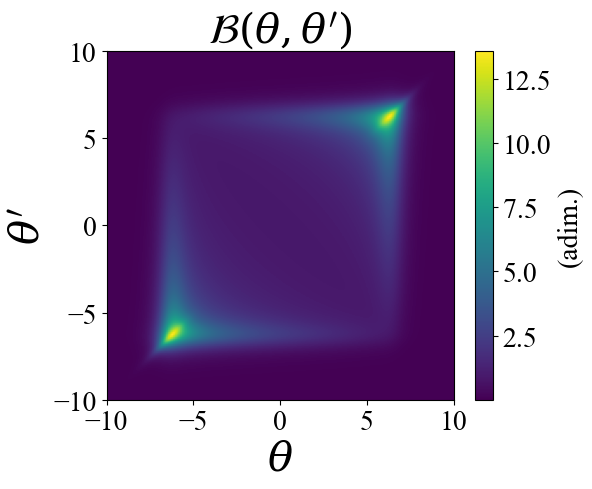

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))  # ✅ crée fig et ax explicitement

im = ax.imshow(Reg * 100, extent=[theta_discr.min(), theta_discr.max(),
                                  theta_discr.min(), theta_discr.max()],
               origin="lower", aspect="auto", cmap="viridis")

# Barre de couleur
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("(adim.)", fontsize=20)

# Axes et titres
ax.set_xlabel(r"$\theta$", fontsize=30)
ax.set_ylabel(r"$\theta'$", fontsize=30)
ax.set_title(r"$\mathcal{B}(\theta, \theta')$", fontsize=30)

# Fond transparent
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# Ticks plus gros
ax.tick_params(axis='both', which='major', labelsize=20)
cbar.ax.tick_params(labelsize=20)

# Sauvegarde avec fond transparent
fig.tight_layout()
fig.savefig("fluctu_1.png", dpi=300, bbox_inches="tight", transparent=True)

plt.show()


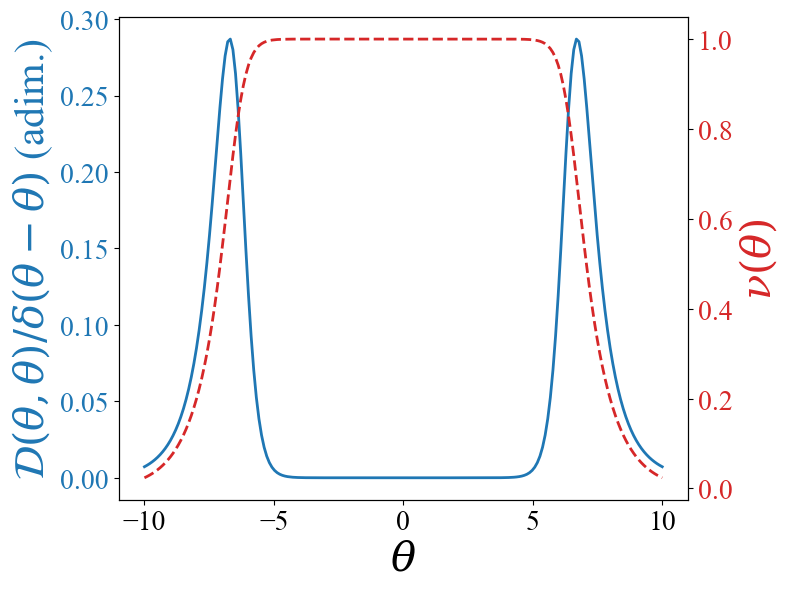

In [51]:
fig, ax1 = plt.subplots(figsize=(8,6))

# Axe gauche : f_vals
ax1.plot(theta_discr, f_vals, lw=2, color='tab:blue', label=r"$\rho_s \nu(1-\nu)$")
ax1.set_xlabel(r"$\theta$", fontsize=30)
ax1.set_ylabel(r"$\mathcal{D}(\theta,\theta)/\delta(\theta-\theta)$ (adim.)", fontsize=30, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.tick_params(axis='both', which='major', labelsize=20)


# Axe droit : nu_discr
ax2 = ax1.twinx()
ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.plot(theta_discr, nu_discr, lw=2, color='tab:red', linestyle='--', label=r"$\nu(\theta)$")
ax2.set_ylabel(r"$\nu(\theta)$", fontsize=30, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Grille et mise en forme
fig.tight_layout()
fig.savefig("diag_fluctu_2axes.png", dpi=300, bbox_inches="tight")
plt.show()


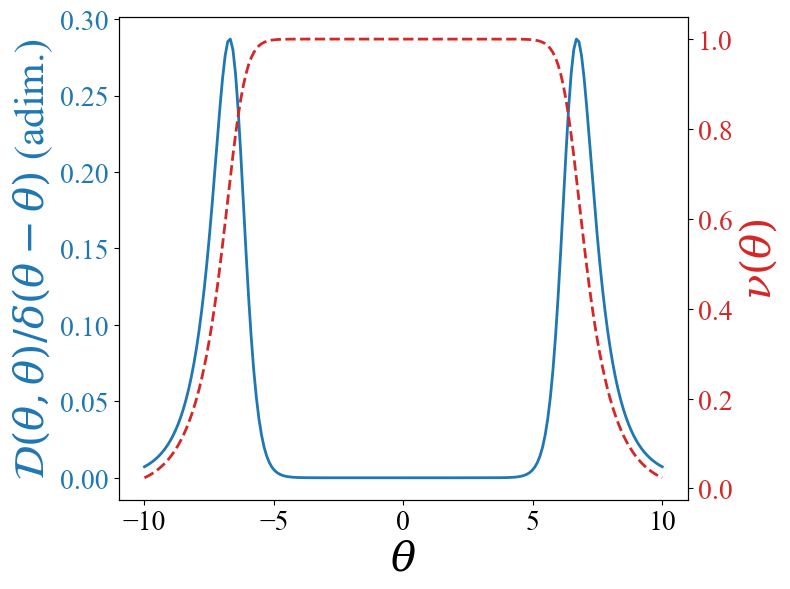

In [52]:
fig, ax1 = plt.subplots(figsize=(8,6))

# Axe gauche
ax1.plot(theta_discr, f_vals, lw=2, color='tab:blue', label=r"$\rho_s \nu(1-\nu)$")
ax1.set_xlabel(r"$\theta$", fontsize=30)
ax1.set_ylabel(r"$\mathcal{D}(\theta,\theta)/\delta(\theta-\theta)$ (adim.)", fontsize=30, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=20)
ax1.tick_params(axis='x', labelsize=20)

# Axe droit
ax2 = ax1.twinx()
ax2.plot(theta_discr, nu_discr, lw=2, color='tab:red', linestyle='--', label=r"$\nu(\theta)$")
ax2.set_ylabel(r"$\nu(\theta)$", fontsize=30, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=20)
ax2.tick_params(axis='x', labelsize=20)

# Fond transparent
fig.patch.set_alpha(0)
ax1.patch.set_alpha(0)
ax2.patch.set_alpha(0)

fig.tight_layout()
fig.savefig("diag_fluctu_2axes.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()


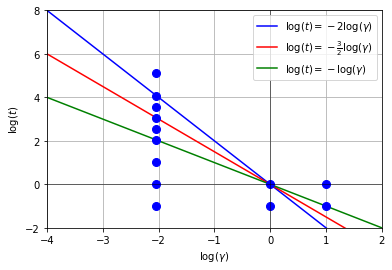

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Définir les équations des droites
def line_1(x):
    return -2 * x  

def line_2(x):
    return -3/2 * x  

def line_3(x):
    return -x  

# Créer un ensemble de valeurs pour t
x_values = np.linspace(-5, 5, 400)

# Calculer les valeurs correspondantes de gamma (y)
y_1 = line_1(x_values)
y_2 = line_2(x_values)
y_3 = line_3(x_values)

# Tracer les droites
plt.plot(x_values, y_1, label=r"$\log(t) = -2\log(\gamma)$", color='b')  # Première droite
plt.plot(x_values, y_2, label=r"$\log(t) = -\frac{3}{2}\log(\gamma)$", color='r')  # Deuxième droite
plt.plot(x_values, y_3, label=r"$\log(t) = -\log(\gamma)$", color='g')  # Troisième droite

# Liste des points
gamma = -2.04
Points = [ (0, 0) , (1,0 ) , (1,0.5*gamma ) , (0 ,0.5*gamma ) ,  (gamma,0.5*gamma) , (gamma,0) ,(gamma,-0.5*gamma), (gamma,-gamma) , (gamma,(-1 -3/2)/2*gamma) , (gamma,-3/2*gamma) , (gamma,(-3/2-2)/2*gamma) , (gamma,-2*gamma), (gamma,-2.5*gamma)   ]

# Tracer les points
for point in Points:
    plt.plot([point[0]], [point[1]], color='blue', marker='o', markersize=8)

# Ajouter des étiquettes et un titre
#plt.title("Graphique des droites et de la norme infinie $\|(\gamma, t)\|_\infty = 1$")
plt.xlabel(r"$\log(\gamma)$")
plt.ylabel(r"$\log(t)$")
plt.legend()

# Afficher le graphique
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)  # Axe horizontal
plt.axvline(0, color='black',linewidth=0.5)  # Axe vertical

# Définir les limites des axes
plt.xlim([-4, 2])  # Limite de l'axe des abscisses
plt.ylim([-2, 8])  # Limite de l'axe des ordonnées (ajustable selon tes besoins)

# Ajouter une grille et afficher le graphique
plt.grid(True)

plt.show()


In [11]:
import numpy as np

# Définir les constantes
hbar = 1.05457182e-25   # um^2.kg/ms
mass =  1.44e-25        # kg (masse du Rubidium 87)
kB = 1.380649e-26       # um^2.ms^-2.kg.nK^{-1}
a3D = 5.3e-3            # um
om_perp = 2 * np.pi * 5 # 2.56  # kHz (fréquence transversale)

# Calculer les constantes dérivées
g = 2 * hbar * a3D * om_perp        # force de répulsion effective 1D
c = mass / hbar**2 * g              # um^{-1}
gbar = g / hbar                     # um.ms^{-1}

# Afficher les résultats
print(f"g = {g} um.ms^-1")
print(f"c = {c} um^-1")
print(f"gbar = {gbar} um.ms^-1")

print(f"m/hbar = {mass/hbar} um^{-2}.ms^1")
print(f"m/hbar^2 = {mass/hbar**2} um^{-4}.kg^{-1}.ms^2")
print(f"kB.hbar^2/m = {kB*hbar**2/mass} um^{6}.kg^{2}.ms^{-4}.nK^{-1}")

g = 3.511817187338507e-26 um.ms^-1
c = 0.4547179182579959 um^-1
gbar = 0.33300882128051806 um.ms^-1
m/hbar = 1.3654831019474805 um^-2.ms^1
m/hbar^2 = 1.2948222928500785e+25 um^-4.kg^-1.ms^2
kB.hbar^2/m = 1.0662845454730357e-51 um^6.kg^2.ms^-4.nK^-1


In [12]:
nom = "Reg"

print("date =" , date)
print("nom =" , nom) 
print("mu =" , mu) 
print("T  =" , T) 
print("Taille =", Taille)
print("theta_max =", theta_max)
print("npts =", npts)

nom = "Reg"
Reg = np.load(f"{date}/{nom}_{mu:.3f}_{T:.3f}_{Taille:.3f}_{theta_max:.3f}_{npts:.3f}.npz") 
nom = "inv-A-approx"
print("nom =" , nom)

#A_appox = np.load(f"{date}/{nom}_{mu:.3f}_{T:.3f}_{Taille:.3f}_{theta_max:.3f}_{npts:.3f}.npz")

A_1 = Reg 

date = 2025-06-25
nom = Reg
mu = 24.746
T  = 24.289
Taille = 100.0
theta_max = 5.77
npts = 1000.0
nom = inv-A-approx


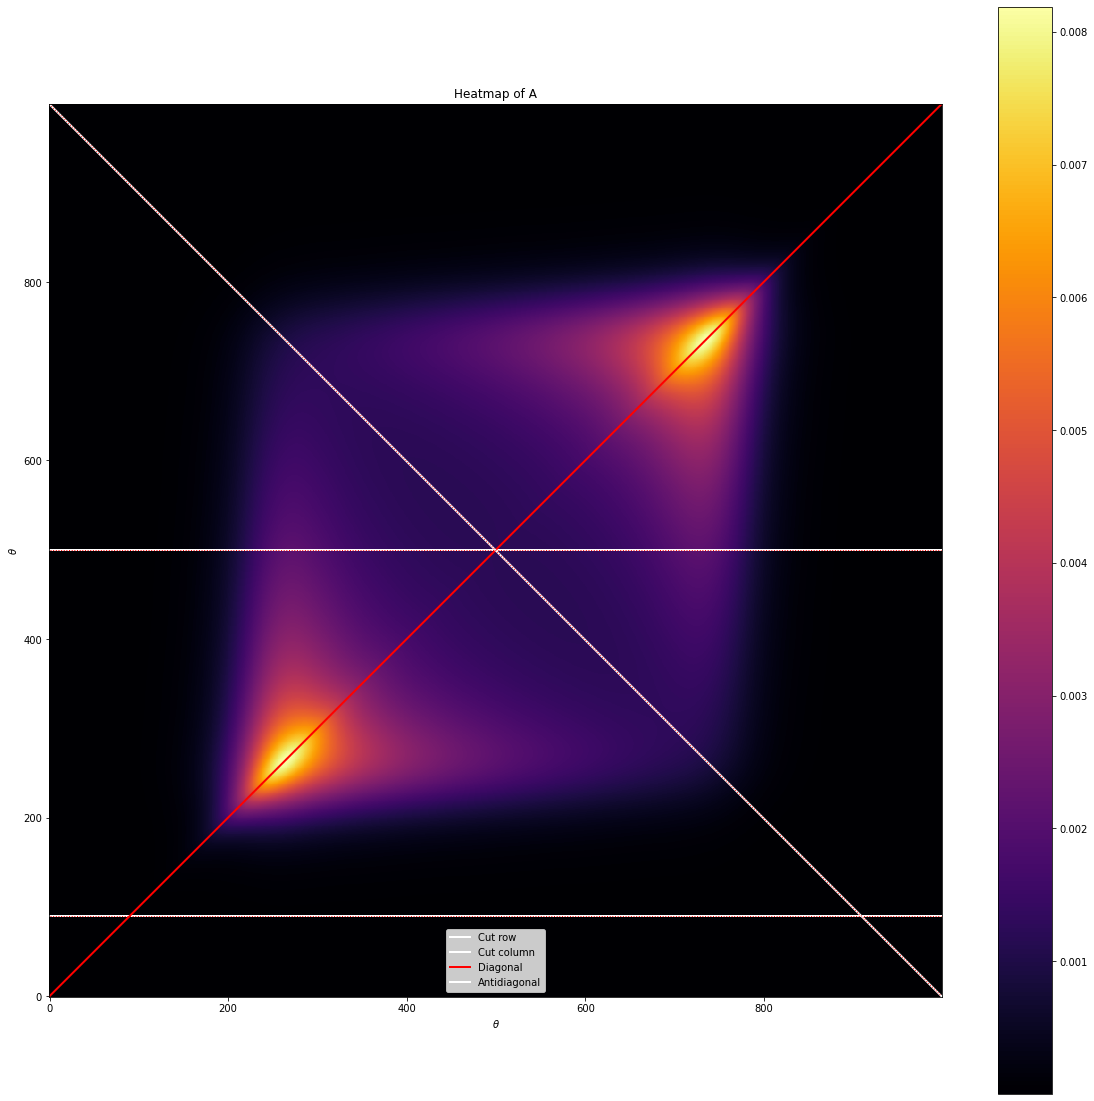

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Charger un exemple de matrice (en remplacement de `A` dans le code Julia)
#A = np.random.rand(10, 10)  # Exemple de matrice 10x10

# Normalisation (similaire à `normalisation = 0.5` en Julia)
normalisation = 0.5 

# Création de la heatmap
plt.figure(figsize=(20, 20))
plt.imshow(A_1, cmap='inferno', interpolation='nearest', origin='lower')
plt.title("Heatmap of A")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\theta$")
plt.colorbar()

# Sélectionner dynamiquement une ligne à couper (coupe horizontale)
cut_row_index = int(A_1.shape[1]/2)  # Exemple de ligne à couper
plt.plot(A_1[cut_row_index, :] * normalisation + cut_row_index, label="Cut row", color='white', linewidth=2)
plt.plot(np.ones(A_1.shape[1]) * cut_row_index, color='red', linestyle=':', linewidth=1)

# Sélectionner dynamiquement une colonne à couper (coupe verticale)
cut_column_index = 90  # Exemple de colonne à couper
plt.plot(A_1[:, cut_column_index] * normalisation + cut_column_index, label="Cut column", color='white', linewidth=2)
plt.plot(np.ones(A_1.shape[0]) * cut_column_index, color='red', linestyle=':', linewidth=1)

# Fonction de rotation autour du point (x0, y0)
def rot_x(x, y, x0, y0, theta):
    return x0 + (x - x0) * np.cos(theta) / np.abs(np.cos(theta)) - (y - y0) * np.sin(theta) / np.abs(np.cos(theta))

def rot_y(x, y, x0, y0, theta):
    return y0 + (x - x0) * np.sin(theta) / np.abs(np.sin(theta)) + (y - y0) * np.cos(theta) / np.abs(np.sin(theta))

# Rotation de la diagonale
theta = np.pi / 4  # 45° en radians
rotated_x = [rot_x(i, A_1[i, i] * normalisation , 0, 0, theta) for i in range(A_1.shape[0])]
rotated_y = [rot_y(i, A_1[i, i] * normalisation , 0, 0, theta) for i in range(A_1.shape[0])]
plt.plot(rotated_x, rotated_y, label="Diagonal", color='red', linewidth=2)
rotated_x = [rot_x(i, 0, 0, 0, theta) for i in range(A_1.shape[0])]
rotated_y = [rot_y(i, 0, 0, 0, theta) for i in range(A_1.shape[1])]
plt.plot(rotated_x, rotated_y, color='red', linestyle=':', linewidth=1)

# Diagonale à 135°
theta = -np.pi / 4  # 135° en radians
rotated_x = [rot_x(i, A_1[i, A_1.shape[1] - i - 1] * normalisation , A_1.shape[0]-1, 0, theta) for i in range(A_1.shape[0])]
rotated_y = [rot_y(i, A_1[i, A_1.shape[1] - i - 1] * normalisation , A_1.shape[1]-1, 0, theta) for i in range(A_1.shape[0])]
plt.plot(rotated_x, rotated_y, label="Antidiagonal", color='white', linewidth=2)

# Ajouter des lignes en pointillés pour les diagonales
rotated_x = [rot_x(i, 0,  A_1.shape[0]-1, 0, theta) for i in range(A_1.shape[0])]
rotated_y = [rot_y(i, 0,  A_1.shape[1]-1, 0, theta) for i in range(A_1.shape[1])]
plt.plot(rotated_x, rotated_y, color='red', linestyle=':', linewidth=1)

# Afficher le graphique
plt.legend()
plt.show()


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_graph(Points, Points_r=None):
    # Définir la plage de valeurs pour x
    x_values = np.linspace(-5, 5, 400)

    # Définir les fonctions des droites
    y_1 = -2 * x_values
    y_2 = -1.5 * x_values
    y_3 = -1 * x_values

    # Créer la figure
    plt.figure(figsize=(8, 6))

    # Tracer les droites
    plt.plot(x_values, y_1, label=r"$\log(t) = -2\log(\gamma)$", color="blue", linewidth=2)
    plt.plot(x_values, y_2, label=r"$\log(t) = -\frac{3}{2}\log(\gamma)$", color="red", linewidth=2)
    plt.plot(x_values, y_3, label=r"$\log(t) = -\log(\gamma)$", color="green", linewidth=2)

    # Tracer les points donnés
    print(Points)
    if Points:
        x_pts, y_pts = zip(*Points)
        plt.scatter(x_pts, y_pts, color="blue", s=60, label=None)

    if Points_r:
        x_pts_r, y_pts_r = zip(*Points_r)
        plt.scatter(x_pts_r, y_pts_r, color="red", s=60, label=None)

    # Ajouter des labels et formatage
    plt.xlabel(r"$\log(\gamma)$")
    plt.ylabel(r"$\log(t)$")
    plt.xlim(-4, 2)
    plt.ylim(-2, 8)
    plt.grid(True)
    plt.legend(loc='upper right')

    # Tracer les axes
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.axvline(0, color='black', linewidth=1, linestyle='--')

    # Afficher le graphique
    plt.tight_layout()
    plt.show()


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_graph(Points, Points_r=None):
    # Définir la plage de valeurs pour x
    x_values = np.linspace(-5, 5, 400)

    # Définir les fonctions des droites
    y_1 = -2 * x_values
    y_2 = -1.5 * x_values
    y_3 = -1 * x_values

    # Créer la figure
    plt.figure(figsize=(8, 8))

    # Tracer les droites
    plt.plot(x_values, y_1, label=r"$\log(t) = -2\log(\gamma)$", color="blue", linewidth=2)
    plt.plot(x_values, y_2, label=r"$\log(t) = -\frac{3}{2}\log(\gamma)$", color="red", linewidth=2)
    plt.plot(x_values, y_3, label=r"$\log(t) = -\log(\gamma)$", color="green", linewidth=2)

    # Tracer les points donnés
    print(Points)
    if Points:
        x_pts, y_pts = zip(*Points)
        plt.scatter(x_pts, y_pts, color="blue", s=60, label=None)

    if Points_r:
        x_pts_r, y_pts_r = zip(*Points_r)
        plt.scatter(x_pts_r, y_pts_r, color="red", s=60, label=None)

    # Ajouter des labels et formatage
    plt.xlabel(r"$\log(\gamma)$", fontsize=20)
    plt.ylabel(r"$\log(t)$", fontsize=20)
    plt.xlim(-4, 2)
    plt.ylim(-2, 8)
    plt.grid(True)
    plt.legend(loc='upper right', fontsize=20)

    # Tracer les axes
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.axvline(0, color='black', linewidth=1, linestyle='--')

    # Afficher le graphique
    plt.tight_layout()

    # Enregistrer l'image
    plt.savefig("diagram.png", dpi=300)

    # Afficher le graphique
    plt.show()

In [4]:
import numpy as np

# Fonction pour charger un fichier .npz
def load_npz_data(file_path):
    data = np.load(file_path)
    return data

# Exemple de récupération des fichiers
new_date = "2025-08-29"  # Remplace cette valeur par la date réelle utilisée dans ton code Julia

# Chargement des matrices à partir des fichiers .npz
points_file = f"{new_date}/Points_2.npz"
FLUC_N1_file = f"{new_date}/FLUC_N1_2.npz"
FLUC_N2_file = f"{new_date}/FLUC_N2_2.npz"
FLUC_E_minus_muN1_file = f"{new_date}/FLUC_E_minus_muN1_2.npz"
FLUC_E_minus_muN2_file = f"{new_date}/FLUC_E_minus_muN2_2.npz"
FLUC_E1_file = f"{new_date}/FLUC_E1_2.npz"
FLUC_E2_file = f"{new_date}/FLUC_E2_2.npz"

# Charger les fichiers
Points2 = load_npz_data(points_file)
FLUC_N1 = load_npz_data(FLUC_N1_file)
FLUC_N2 = load_npz_data(FLUC_N2_file)
FLUC_E_minus_muN1 = load_npz_data(FLUC_E_minus_muN1_file)
FLUC_E_minus_muN2 = load_npz_data(FLUC_E_minus_muN2_file)
FLUC_E1 = load_npz_data(FLUC_E1_file)
FLUC_E2 = load_npz_data(FLUC_E2_file)

# Extraction des données sous forme de tableau numpy
Points2_array = Points2#['arr_0']  # Accessing the data stored in the 'arr_0' key
FLUC_N1_array = [x[0] for x in FLUC_N1]#['arr_0']
FLUC_N2_array = [x[0] for x in FLUC_N2]#['arr_0']
FLUC_E_minus_muN1_array = [x[0] for x in FLUC_E_minus_muN1]#['arr_0']
FLUC_E_minus_muN2_array = [x[0] for x in FLUC_E_minus_muN2]#['arr_0']
FLUC_E1_array = [x[0] for x in FLUC_E1]#['arr_0']
FLUC_E2_array = [x[0] for x in FLUC_E2]#['arr_0']

# Affichage des matrices
print("Points2:", Points2_array)
print("FLUC_N1:", FLUC_N1_array)
print("FLUC_N2:", FLUC_N2_array)
print("FLUC_E_minus_muN1:", FLUC_E_minus_muN1_array)
print("FLUC_E_minus_muN2:", FLUC_E_minus_muN2_array)
print("FLUC_E1:", FLUC_E1_array)
print("FLUC_E2:", FLUC_E2_array)


Points2: [[  -1.7           1.7          49.18922502]
 [  -1.7           1.75         49.47491914]
 [  -1.7           1.8          49.82359644]
 [  -1.7           1.85         50.24512341]
 [  -1.7           1.9          50.74631492]
 [  -1.7           1.95         51.32876205]
 [  -1.7           2.           51.9874495 ]
 [  -1.7           2.05         52.71045325]
 [  -1.7           2.1          53.47949945]
 [  -1.7           2.15         54.27092113]
 [  -1.7           2.2          55.05661307]
 [  -1.7           2.25         55.80478266]
 [  -1.7           2.3          56.48046651]
 [  -1.7           2.35         57.04587274]
 [  -1.7           2.4          57.46063044]
 [  -1.7           2.45         57.68201101]
 [  -1.7           2.5          57.66515327]
 [  -1.7           2.55         57.36328855]
 [  -1.7           2.6          56.7279317 ]
 [  -1.7           2.65         55.70898422]
 [  -1.7           2.7          54.25468991]
 [  -1.7           2.75         52.31139192]
 

[(-1.6999999999999997, 1.7), (-1.6999999999999997, 1.75), (-1.6999999999999997, 1.8), (-1.6999999999999997, 1.85), (-1.6999999999999997, 1.9), (-1.6999999999999997, 1.95), (-1.6999999999999997, 2.0), (-1.6999999999999997, 2.05), (-1.6999999999999997, 2.1), (-1.6999999999999997, 2.15), (-1.6999999999999997, 2.2), (-1.6999999999999997, 2.25), (-1.6999999999999997, 2.3), (-1.6999999999999997, 2.35), (-1.6999999999999997, 2.4), (-1.6999999999999997, 2.45), (-1.6999999999999997, 2.5), (-1.6999999999999997, 2.55), (-1.6999999999999997, 2.6), (-1.6999999999999997, 2.65), (-1.6999999999999997, 2.7), (-1.6999999999999997, 2.75), (-1.6999999999999997, 2.8), (-1.6999999999999997, 2.85), (-1.6999999999999997, 2.9), (-1.6999999999999997, 2.95), (-1.6999999999999997, 3.0), (-1.6999999999999997, 3.05), (-1.6999999999999997, 3.1), (-1.6999999999999997, 3.15), (-1.6999999999999997, 3.2), (-1.6999999999999997, 3.25), (-1.6999999999999997, 3.3), (-1.6999999999999997, 3.35), (-1.6999999999999997, 3.4), (-

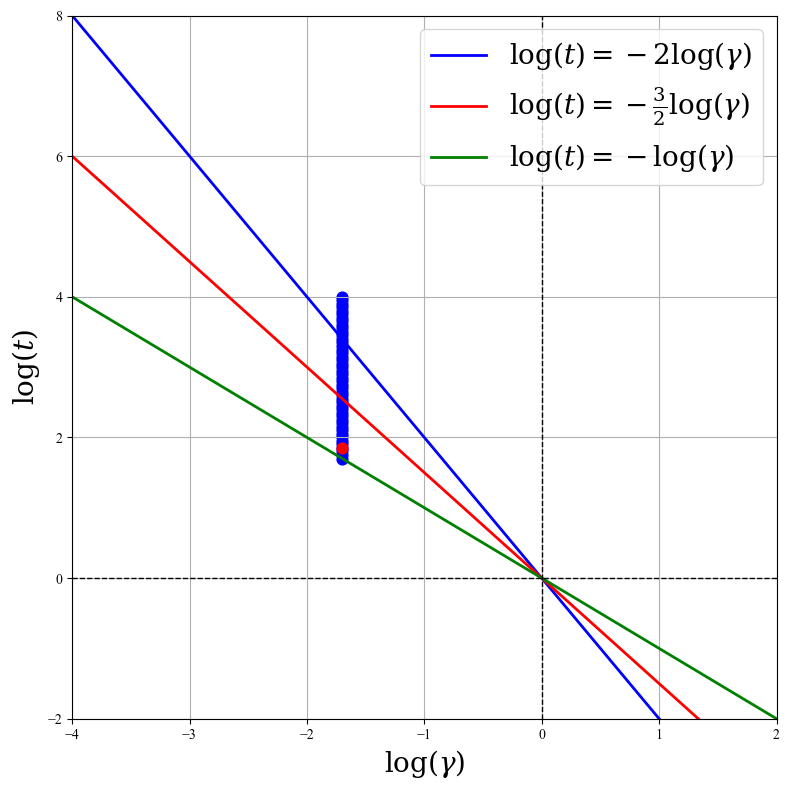

51.736030027156914


In [8]:
#Points = [(-2, 2), (0, 0), (1, -1)]
#Points_r = [(-1, 3), (0.5, -0.5)]
# Définir les constantes
hbar = 1.05457182e-25   # um^2.kg/ms
mass =  1.44e-25        # kg (mass of Rubidium 87)
kB = 1.380649e-26       # um^2.ms^-2.kg.nK^{-1}
a3D = 5.3e-3            # um
om_perp = 2 * np.pi * 5 # 2.56  # kHz (transverse frequency)
# Calculer les constantes dérivées
g = 2 * hbar * a3D * om_perp        # effective 1d repulsion strength
c = mass / hbar**2 * g              # um^{-1}
gbar = g / hbar 

hbar , mass , kB , gbar = 1,1, 1, 1

plot_graph([(x - np.log(mass/hbar**2) , y - np.log(kB*hbar**2/mass)) for (x, y , _ ) in Points2_array] , [(x - np.log(mass/hbar**2) , y - np.log(kB*hbar**2/mass)) for (x, y , _ ) in [Points2_array[3]]])
#plot_graph([(x - np.log(mass/hbar**2) , y - np.log(kB*hbar**2/mass)) for (x, y , _ ) in Points2_array] , [(-1.342- np.log(mass/hbar**2),1.32222222- np.log(kB*hbar**2/mass))])

def f_T(t, gb):
    return t * mass * gb**2 / kB
T = f_T(10**1.7137931, gbar)
print(T)

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from PIL import Image
import os

rcParams['text.usetex'] = True  # Pour les labels en LaTeX

def plot_and_save_graphs(new_date, Points, FLUC_N1, FLUC_N2, FLUC_E_minus_muN1, FLUC_E_minus_muN2, 
                         indice_x, indice_const, min_val=2, max_val=6):

    # Conversion des données en numpy array si ce n'est déjà fait
    Points = np.array(Points)
    FLUC_N1 = np.array(FLUC_N1)
    FLUC_N2 = np.array(FLUC_N2)
    FLUC_E_minus_muN1 = np.array(FLUC_E_minus_muN1)
    FLUC_E_minus_muN2 = np.array(FLUC_E_minus_muN2)

    if indice_x == 1:
        X = Points[:, 0]
        xlabel = r"$\log \gamma$"
    elif indice_x == 2:
        X = Points[:, 1]
        xlabel = r"$\log t$"
    else:
        X = Points[:, 2]
        xlabel = r"$\mu$ (nK)"

    # Application du masque pour filtrer les données
    mask = (X >= min_val) & (X <= max_val)

    X_filtered = X[mask]
    FLUC_N1_filtered = FLUC_N1[mask]
    FLUC_N2_filtered = FLUC_N2[mask]
    FLUC_E_minus_muN1_filtered = FLUC_E_minus_muN1[mask]
    FLUC_E_minus_muN2_filtered = FLUC_E_minus_muN2[mask]

    # Construction des titres
    if indice_const == 1:
        log_gamma = Points[0][0]
        titre1 = rf"$\langle N^2 \rangle$, $\log(\gamma) = {log_gamma:.3f}$"
        titre2 = rf"$\langle (E - \mu N)^2 \rangle$, $\log(\gamma) = {log_gamma:.3f}$"
        titre3 = rf"$\frac{{\langle N^2_1 \rangle - \langle N^2_2 \rangle}}{{\langle N^2_1 \rangle}} \times 100$, $\log(\gamma) = {log_gamma:.3f}$"
        titre4 = rf"$\frac{{\langle (E_1 - \mu N_1)^2 \rangle - \langle (E_2 - \mu N_2)^2 \rangle}}{{\langle (E_1 - \mu N_1)^2 \rangle}} \times 100$, $\log(\gamma) = {log_gamma:.3f}$"
        filename = f"{new_date}/fluctuations_plot_log_gamma={log_gamma:.3f}.png"       
        filename_r = f"{new_date}/fluctuations_relativ_plot_log_gamma={log_gamma:.3f}.png"
        filename0 = f"fluctuations_plot_log_gamma={log_gamma:.3f}.png"
        filename_r0 = f"fluctuations_relativ_plot_log_gamma={log_gamma:.3f}.png"
    elif indice_const == 2:
        log_t = Points[0][1]
        titre1 = rf"$\langle N^2 \rangle$, $\log(t) = {log_t:.3f}$"
        titre2 = rf"$\langle (E - \mu N)^2 \rangle$, $\log(t) = {log_t:.3f}$"
        titre3 = rf"$\frac{{\langle N^2_1 \rangle - \langle N^2_2 \rangle}}{{\langle N^2_1 \rangle}} \times 100$, $\log(t) = {log_t:.3f}$"
        titre4 = rf"$\frac{{\langle (E_1 - \mu N_1)^2 \rangle - \langle (E_2 - \mu N_2)^2 \rangle}}{{\langle (E_1 - \mu N_1)^2 \rangle}} \times 100$, $\log(t) = {log_t:.3f}$"
        filename = f"{new_date}/fluctuations_plot_log_t={log_t:.3f}.png"
        filename_r = f"{new_date}/fluctuations_relativ_plot_log_ta={log_t:.3f}.png"
        filename0 = f"fluctuations_plot_log_t={log_t:.3f}.png"
        filename_r0 = f"fluctuations_relativ_plot_log_ta={log_t:.3f}.png"
    else:
        mu = Points[0][2]
        titre1 = rf"$\langle N^2 \rangle$, $\mu = {mu:.3f}$ nK"
        titre2 = rf"$\langle (E - \mu N)^2 \rangle$, $\mu = {mu:.3f}$ nK"
        titre3 = rf"$\frac{{\langle N^2_1 \rangle - \langle N^2_2 \rangle}}{{\langle N^2_1 \rangle}} \times 100$, $\mu = {mu:.3f}$ nK"
        titre4 = rf"$\frac{{\langle (E_1 - \mu N_1)^2 \rangle - \langle (E_2 - \mu N_2)^2 \rangle}}{{\langle (E_1 - \mu N_1)^2 \rangle}} \times 100$, $\mu = {mu:.3f}$ nK"
        filename = f"{new_date}/fluctuations_plot_mu={mu:.3f}.png"
        filename_r = f"{new_date}/fluctuations_relativ_plot_mu={mu:.3f}.png"
        filename0 = f"fluctuations_plot_mu={mu:.3f}.png"
        filename_r0 = f"fluctuations_relativ_plot_mu={mu:.3f}.png"
    # Tracé des graphiques
    fig1, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(X_filtered, FLUC_N1_filtered, 'o-', label=r"$\frac{1}{\beta} \left. \frac{\partial \langle \mathcal{N} \rangle}{\partial \mu} \right|_T$")
    axes[0].plot(X_filtered, FLUC_N2_filtered, 's-', label=r"$\langle (\mathcal{N} - \langle \mathcal{N} \rangle )^2 \rangle$")
    axes[0].set_title(titre1)
    axes[0].set_ylabel(r"Fluctuation de $\mathcal{N}$")
    axes[0].set_xlabel(xlabel)
    axes[0].legend()

    axes[1].plot(X_filtered, FLUC_E_minus_muN1_filtered, 'd-', label=r"$- \left. \frac{\partial \langle \mathcal{E} - \mu \mathcal{N} \rangle}{\partial \beta} \right|_\mu.$")
    axes[1].plot(X_filtered, FLUC_E_minus_muN2_filtered, '^-', label=r"$\left \langle  \left (  (\mathcal{E} - \mu \mathcal{N}  ) -  \langle\mathcal{E} - \mu \mathcal{N} \rangle  \right )^2  \right \rangle$")
    axes[1].set_title(titre2)
    axes[1].set_ylabel(r"Fluctuation de $\mathcal{E} - \mu \mathcal{N} ~ (nK)$ ")
    axes[1].set_xlabel(xlabel)
    axes[1].legend()

    os.makedirs(new_date, exist_ok=True)
    #filename = f"{new_date}/fluctuations_plot_log_gamma={log_gamma:.3f}.png"
    plt.tight_layout()
    plt.savefig(filename)
    plt.savefig(filename0)
    plt.show()
    plt.close(fig1)
    print(f"Graphique sauvegardé sous '{filename}'")

    # Calcul du taux de variation relatif
    mask_N = FLUC_N1_filtered != 0
    mask_E = FLUC_E_minus_muN1_filtered != 0

    relative_N = np.zeros_like(FLUC_N1_filtered)
    relative_E = np.zeros_like(FLUC_E_minus_muN1_filtered)

    relative_N[mask_N] = (FLUC_N1_filtered[mask_N] - FLUC_N2_filtered[mask_N]) / FLUC_N1_filtered[mask_N]
    relative_E[mask_E] = (FLUC_E_minus_muN1_filtered[mask_E] - FLUC_E_minus_muN2_filtered[mask_E]) / FLUC_E_minus_muN1_filtered[mask_E]

    fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(X_filtered, relative_N * 100, 'o-', label="Variation relative N")
    axes[0].set_title(titre3)
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Variation relative $\mathcal{N}$ Pourcentage $\%$")

    axes[1].plot(X_filtered, relative_E * 100, 'd-', label="Variation relative E")
    axes[1].set_title(titre4)
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(r"Variation relative $\mathcal{E} - \mu \mathcal{N}$ Pourcentage $\%$")

    #filename_r = f"{new_date}/fluctuations_relativ_plot_log_gamma={log_gamma:.3f}.png"
    plt.tight_layout()
    plt.savefig(filename_r)
    plt.savefig(filename_r0)
    plt.show()
    plt.close(fig2)
    print(f"Graphique sauvegardé sous '{filename_r}'")

    # Affichage de l’image (optionnel)
    img = Image.open(filename)
    img.show()
    img_r = Image.open(filename_r)
    img_r.show()


<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_14292/1416318774.py:108: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel("Variation relative $\mathcal{N}$ Pourcentage $\%$")


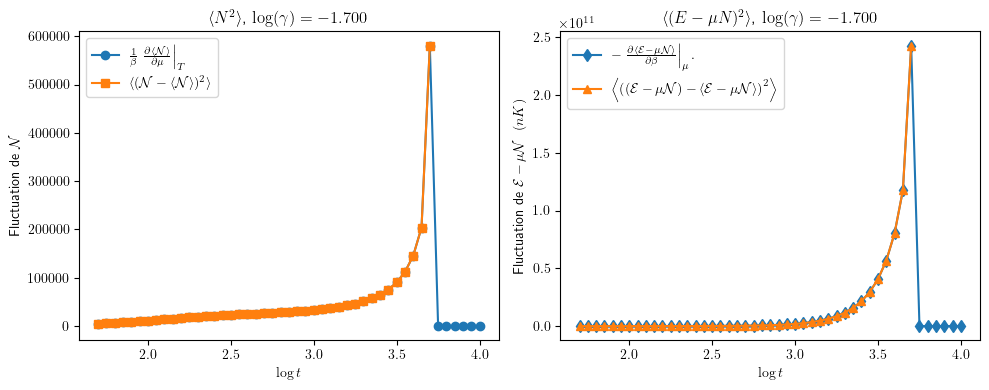

Graphique sauvegardé sous '2025-08-29/fluctuations_plot_log_gamma=-1.700.png'


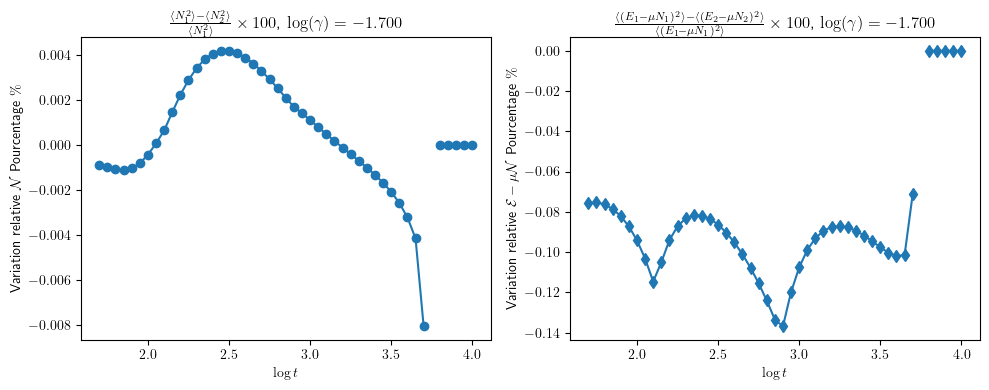

Graphique sauvegardé sous '2025-08-29/fluctuations_relativ_plot_log_gamma=-1.700.png'


In [40]:
plot_and_save_graphs(new_date, Points2_array, FLUC_N1_array, FLUC_N2_array, FLUC_E_minus_muN1_array, FLUC_E_minus_muN2_array, 
                         indice_x=2, indice_const=1, min_val=0, max_val=6)

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from PIL import Image
import os

rcParams['text.usetex'] = True  # Pour les labels en LaTeX

def plot_and_save_graphs(new_date, Points, FLUC_N1, FLUC_N2, FLUC_E1, FLUC_E2, 
                         indice_x, indice_const, min_val=2, max_val=6):

    # Conversion des données en numpy array si ce n'est déjà fait
    Points = np.array(Points)
    FLUC_N1 = np.array(FLUC_N1)
    FLUC_N2 = np.array(FLUC_N2)
    FLUC_E1 = np.array(FLUC_E1)
    FLUC_E2 = np.array(FLUC_E2)

    if indice_x == 1:
        X = Points[:, 0]
        xlabel = r"$\log \gamma$"
    elif indice_x == 2:
        X = Points[:, 1]
        xlabel = r"$\log t$"
    else:
        X = Points[:, 2]
        xlabel = r"$\mu$ (nK)"

    # Application du masque pour filtrer les données
    mask = (X >= min_val) & (X <= max_val)

    X_filtered = X[mask]
    FLUC_N1_filtered = FLUC_N1[mask]
    FLUC_N2_filtered = FLUC_N2[mask]
    FLUC_E1_filtered = FLUC_E1[mask]
    FLUC_E2_filtered = FLUC_E2[mask]

    # Construction des titres
    if indice_const == 1:
        log_gamma = Points[0][0]
        titre1 = rf"$\langle \hat{{\mathcal{{Q}}}}^2 \rangle_w$, $\log(\gamma) = {log_gamma:.3f}$"
        titre2 = rf"$\langle \hat{{\mathcal{{H}}}}^2  \rangle_w$, $\log(\gamma) = {log_gamma:.3f}$"
        titre3 = rf"$\frac{{\langle N^2_1 \rangle - \langle N^2_2 \rangle}}{{\langle N^2_1 \rangle}} \times 100$, $\log(\gamma) = {log_gamma:.3f}$"
        titre4 = rf"$\frac{{\langle H_1^2 \rangle - \langle H_2^2 \rangle}}{{\langle H_1^2 \rangle}} \times 100$, $\log(\gamma) = {log_gamma:.3f}$"
        titre3 = rf"$\frac{{C_w[f_0,f_0] - \chi_w[f_0,f_0]}}{{C_w[f_0,f_0]}} \times 100$, $\log(\gamma) = {log_gamma:.3f}$"
        titre4 = rf"$\frac{{C_w[f_2,f_2] - \chi_w[f_2,f_2]}}{{C_w[f_2,f_2]}} \times 100$, $\log(\gamma) = {log_gamma:.3f}$"
       
        filename = f"{new_date}/fluctuations_plot_log_gamma={log_gamma:.3f}.png"       
        filename_r = f"{new_date}/fluctuations_relativ_plot_log_gamma={log_gamma:.3f}.png"
        filename0 = f"fluctuations_plot_log_gamma={log_gamma:.3f}.png"
        filename_r0 = f"fluctuations_relativ_plot_log_gamma={log_gamma:.3f}.png"
    elif indice_const == 2:
        log_t = Points[0][1]
        titre1 = rf"$\langle \hat{{\mathcal{{Q}}}}^2  \rangle$, $\log(t) = {log_t:.3f}$"
        titre2 = rf"$\langle \hat{{\mathcal{{H}}}}^2  \rangle$, $\log(t) = {log_t:.3f}$"
        titre3 = rf"$\frac{{\langle N^2_1 \rangle - \langle N^2_2 \rangle}}{{\langle N^2_1 \rangle}} \times 100$, $\log(t) = {log_t:.3f}$"
        titre4 = rf"$\frac{{\langle H_1^2 \rangle - \langle H_2^2 \rangle}}{{\langle H_1^2 \rangle}} \times 100$, $\log(t) = {log_t:.3f}$"
        filename = f"{new_date}/fluctuations_plot_log_t={log_t:.3f}.png"
        filename_r = f"{new_date}/fluctuations_relativ_plot_log_ta={log_t:.3f}.png"
        filename0 = f"fluctuations_plot_log_t={log_t:.3f}.png"
        filename_r0 = f"fluctuations_relativ_plot_log_ta={log_t:.3f}.png"
    else:
        mu = Points[0][2]
        titre1 = rf"$\langle \hat{{\mathcal{{Q}}}}^2  \rangle$, $\mu = {mu:.3f}$ nK"
        titre2 = rf"$\langle \hat{{\mathcal{{H}}}}^2  \rangle$, $\mu = {mu:.3f}$ nK"
        titre3 = rf"$\frac{{\langle N^2_1 \rangle - \langle N^2_2 \rangle}}{{\langle N^2_1 \rangle}} \times 100$, $\mu = {mu:.3f}$ nK"
        titre4 = rf"$\frac{{\langle H_1^2 \rangle - \langle H_2^2 \rangle}}{{\langle H_1^2 \rangle}} \times 100$, $\mu = {mu:.3f}$ nK"
        filename = f"{new_date}/fluctuations_plot_mu={mu:.3f}.png"
        filename_r = f"{new_date}/fluctuations_relativ_plot_mu={mu:.3f}.png"
        filename0 = f"fluctuations_plot_mu={mu:.3f}.png"
        filename_r0 = f"fluctuations_relativ_plot_mu={mu:.3f}.png"
    # Tracé des graphiques
    fig1, axes = plt.subplots(1, 2, figsize=(10, 4))
    #axes[0].plot(X_filtered, FLUC_N1_filtered, 'o-', label=r"$\frac{1}{\beta} \left. \frac{\partial \langle \hat{N} \rangle}{\partial \mu} \right|_\beta$")
    #axes[0].plot(X_filtered, FLUC_N2_filtered, 's-', label=r"$\langle (\hat{N} - \langle \hat{N} \rangle )^2 \rangle$")
    axes[0].plot(X_filtered, FLUC_N1_filtered, 'o-', color="red", linewidth=2.5,  label=r"$C_w[f_0,f_0]$")
    axes[0].plot(X_filtered, FLUC_N2_filtered, 'x--', color="blue", linewidth=1.5 ,  label=r"$\chi_w[f_0,f_0]$")
    axes[0].set_title(titre1)
    axes[0].set_ylabel(r"Fluctuation de $\hat{\mathcal{Q}}$")
    axes[0].set_xlabel(xlabel)
    axes[0].legend()

    axes[1].plot(X_filtered, FLUC_E1_filtered,  'o-', color="red", linewidth=2.5,  label=r"$C_w[f_2,f_2]$")
    axes[1].plot(X_filtered, FLUC_E2_filtered, 'x--', color="blue", linewidth=1.5 ,  label=r"$\chi_w[f_2,f_2]$")
    axes[1].set_title(titre2)
    axes[1].set_ylabel(r"Fluctuation de $\hat{\mathcal{H}}/g ~ $ ")
    axes[1].set_xlabel(xlabel)
    axes[1].legend()

    os.makedirs(new_date, exist_ok=True)
    #filename = f"{new_date}/fluctuations_plot_log_gamma={log_gamma:.3f}.png"
    plt.tight_layout()
    plt.savefig(filename)
    plt.savefig(filename0)
    plt.show()
    plt.close(fig1)
    print(f"Graphique sauvegardé sous '{filename}'")

    # Calcul du taux de variation relatif
    mask_N = FLUC_N1_filtered != 0
    mask_E = FLUC_E1_filtered != 0

    relative_N = np.zeros_like(FLUC_N1_filtered)
    relative_E = np.zeros_like(FLUC_E1_filtered)

    relative_N[mask_N] = (FLUC_N1_filtered[mask_N] - FLUC_N2_filtered[mask_N]) / FLUC_N1_filtered[mask_N]
    relative_E[mask_E] = (FLUC_E1_filtered[mask_E] - FLUC_E2_filtered[mask_E]) / FLUC_E1_filtered[mask_E]

    fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(X_filtered, relative_N * 100, 'o-', label="Variation relative N")
    axes[0].set_title(titre3)
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Variation relative $\hat{\mathcal{Q}}$ Pourcentage $\%$")

    axes[1].plot(X_filtered, relative_E * 100, 'd-', label="Variation relative E")
    axes[1].set_title(titre4)
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(r"Variation relative $\hat{\mathcal{H}}$ Pourcentage $\%$")

    #filename_r = f"{new_date}/fluctuations_relativ_plot_log_gamma={log_gamma:.3f}.png"
    plt.tight_layout()
    plt.savefig(filename_r)
    plt.savefig(filename_r0)
    plt.show()
    plt.close(fig2)
    print(f"Graphique sauvegardé sous '{filename_r}'")

    # Affichage de l’image (optionnel)
    img = Image.open(filename)
    img.show()
    img_r = Image.open(filename_r)
    img_r.show()


<>:113: SyntaxWarning: invalid escape sequence '\h'
<>:113: SyntaxWarning: invalid escape sequence '\h'
/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_14292/2115403991.py:113: SyntaxWarning: invalid escape sequence '\h'
  axes[0].set_ylabel("Variation relative $\hat{\mathcal{Q}}$ Pourcentage $\%$")


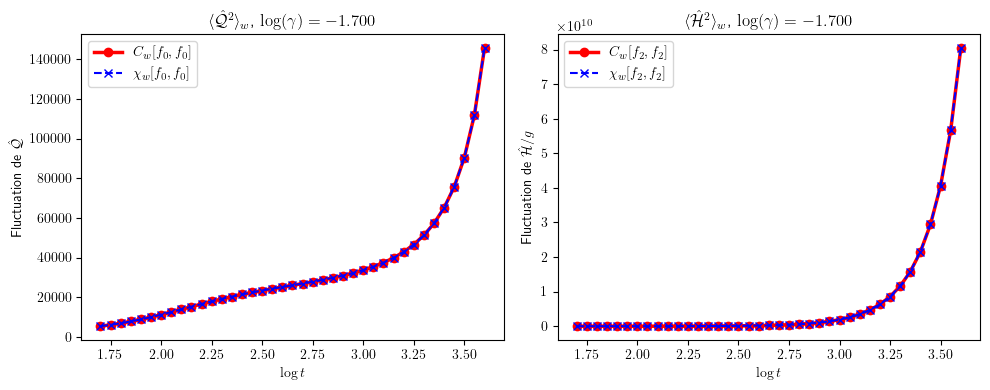

Graphique sauvegardé sous '2025-08-29/fluctuations_plot_log_gamma=-1.700.png'


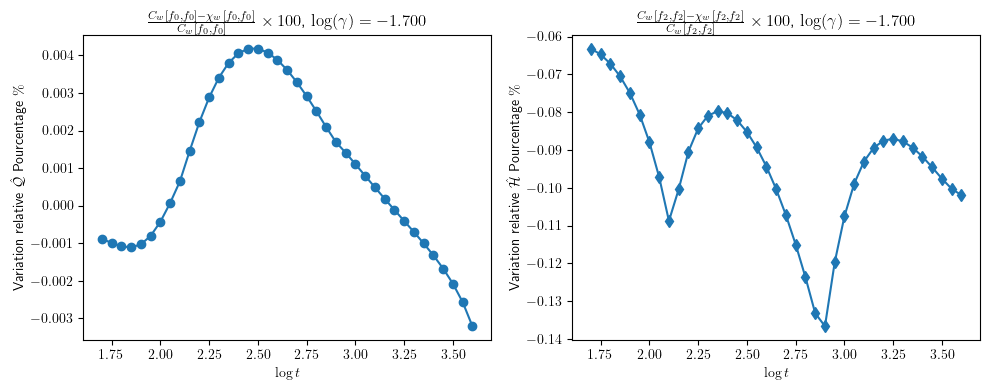

Graphique sauvegardé sous '2025-08-29/fluctuations_relativ_plot_log_gamma=-1.700.png'


In [62]:
plot_and_save_graphs(new_date, Points2_array, FLUC_N1_array, FLUC_N2_array, FLUC_E1_array, FLUC_E2_array, 
                         indice_x=2, indice_const=1, min_val=1.7, max_val=3.6)

20 100000


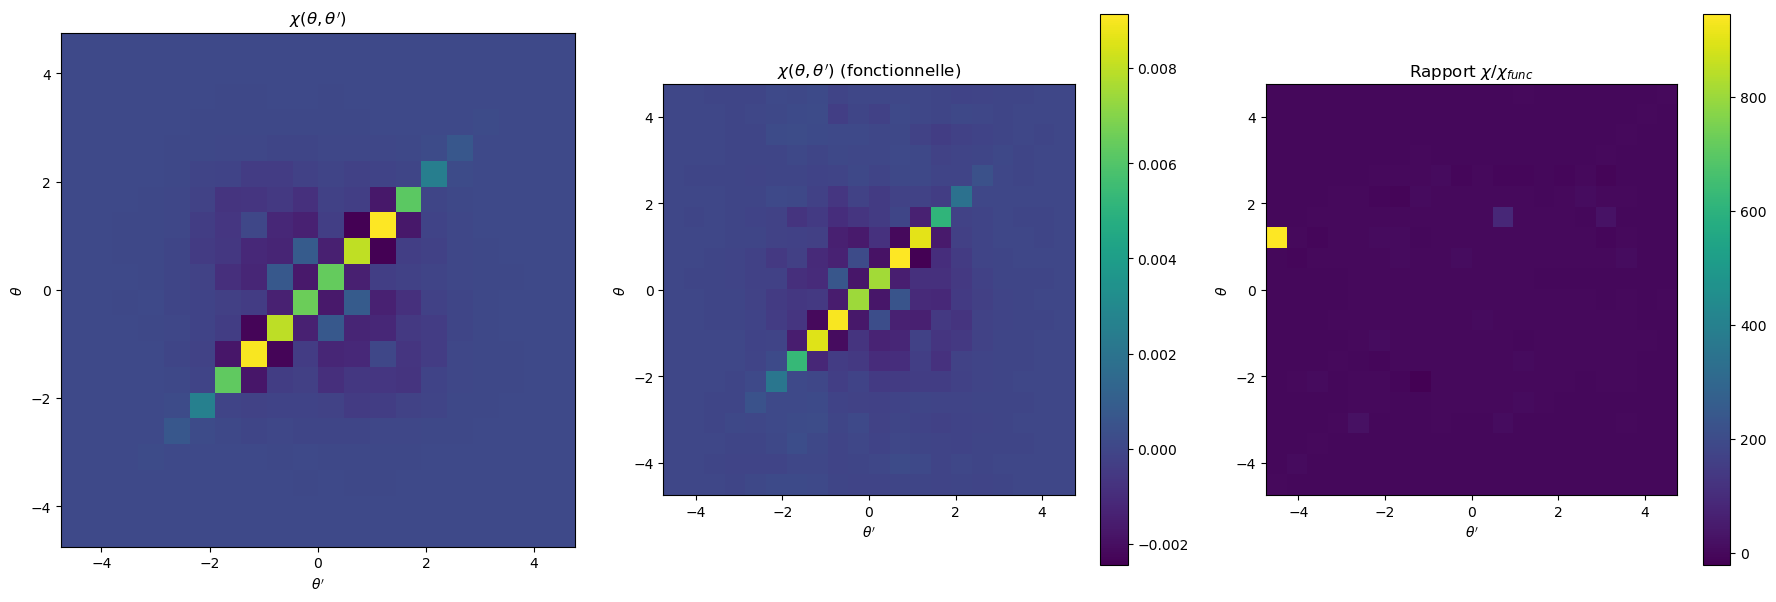

In [59]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Charger le fichier JLD2
filename0 = "/Volumes/BLEU 128/Synchronisation/These_Memoire/figures/04_GGE_Fluctuation/w=0.5*θ^2/"
filename0 = "./w=0.5*θ^2/"

fullpath = filename0+"Sus_N7_L10.0_c1.0_nbin20_nsteps2000000_eps0.1.jld2"  # à adapter
fullpath = filename0+"Sus_N7_L10.0_c1.0_nbin100_nsteps100000_eps1.0.jld2"
fullpath = filename0+"Sus_N7_L10.0_c1.0_nbin100_nsteps100000_eps10.0.jld2"
fullpath = filename0+"Sus_N7_L10.0_c1.0_nbin100_nsteps100000_eps100.0.jld2"
fullpath = filename0+"Sus_N7_L10.0_c1.0_nbin20_nsteps100000_eps1.0.jld2"
with h5py.File(fullpath, "r") as f:
    chi_from_derivative = np.array(f["chi_from_derivative"])
    mean_rho_0 = np.array(f["mean_rho_0"])
    delta_rho_0 = np.array(f["delta_rho_0"])
    chi_matrix_0  = np.cov(delta_rho_0.T, rowvar=False)
    theta_centers = np.array(f["theta_centers"])

print(len(delta_rho_0) , len(delta_rho_0[0]))

# --- Création des figures ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap 1 : chi_matrix_0
im1 = axs[0].imshow(chi_matrix_0, 
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    origin="lower", aspect="equal")
axs[0].set_title(r"$\chi(\theta,\theta')$")
axs[0].set_xlabel(r"$\theta'$")
axs[0].set_ylabel(r"$\theta$")
#fig.colorbar(im1, ax=axs[0])

# Heatmap 2 : chi_from_derivative
im2 = axs[1].imshow(chi_from_derivative, 
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    origin="lower", aspect="equal")
axs[1].set_title(r"$\chi(\theta,\theta')$ (fonctionnelle)")
axs[1].set_xlabel(r"$\theta'$")
axs[1].set_ylabel(r"$\theta$")
fig.colorbar(im2, ax=axs[1])

# Heatmap 3 : ratio
ratio = (chi_matrix_0 + 1e-10) / (chi_from_derivative + 1e-10)
im3 = axs[2].imshow(ratio, 
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    origin="lower", aspect="equal")
axs[2].set_title(r"Rapport $\chi / \chi_{func}$")
axs[2].set_xlabel(r"$\theta'$")
axs[2].set_ylabel(r"$\theta$")
fig.colorbar(im3, ax=axs[2])

plt.tight_layout()
plt.show()

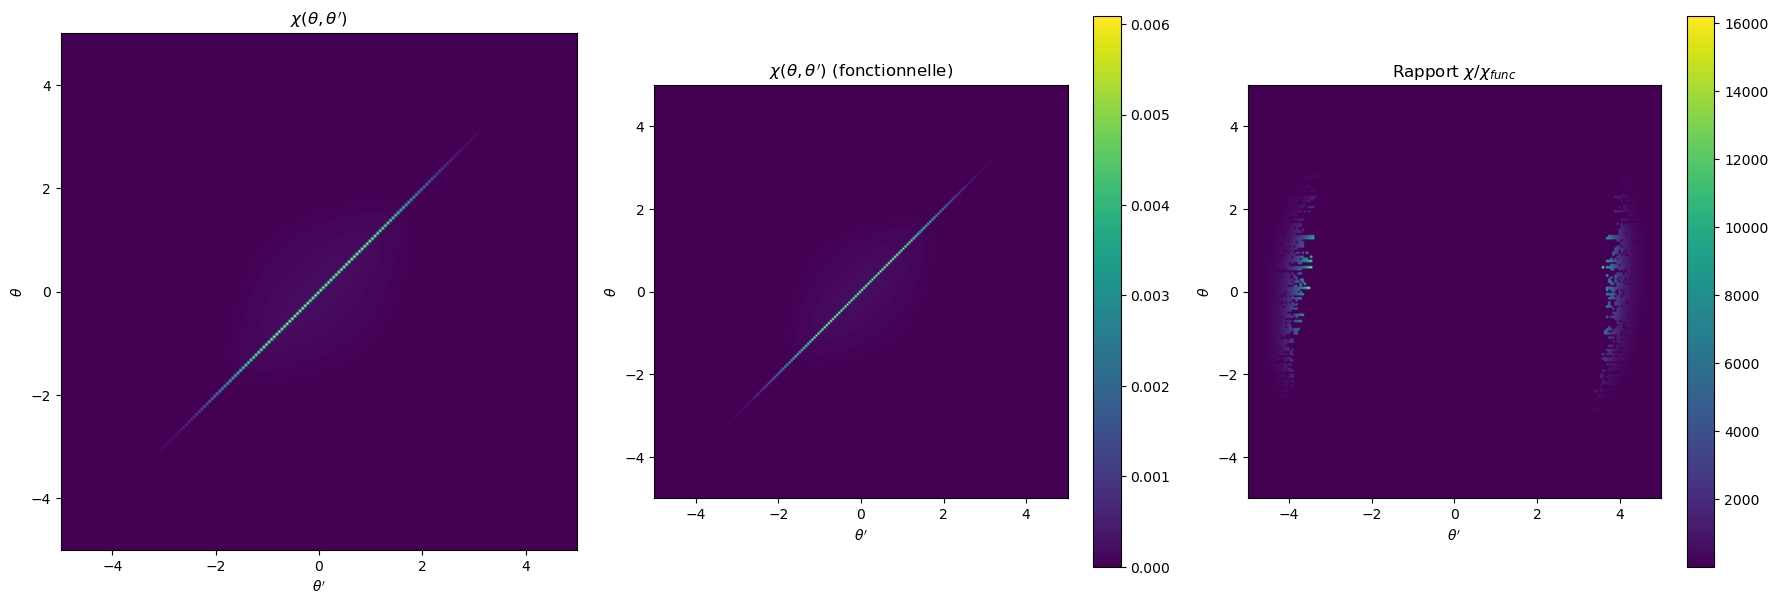

In [23]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Charger le fichier JLD2
filename0 = "/Volumes/BLEU 128/Synchronisation/These_Memoire/figures/04_GGE_Fluctuation/2025-08-29/"
import numpy as np

filename0 = "./2025-08-29/"

fullpath = filename0 + "theta_discr_w_5.000_200.000.npz"  # à adapter
# Charger le fichier .npz
theta_discr = np.load(fullpath)

fullpath = filename0 + "Reg_w_10.000_5.000_200.000.npz"
Reg = np.load(fullpath)

fullpath = filename0 + "Irreg_w_10.000_5.000_200.000.npz"
Irreg = np.load(fullpath)

fullpath = filename0 + "Sus_w_10.000_5.000_200.000.npz"
Sus = np.load(fullpath)

theta_centers = theta_discr
chi_matrix_0 = Reg + Irreg
chi_from_derivative = Sus
# --- Création des figures ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap 1 : chi_matrix_0
im1 = axs[0].imshow(chi_matrix_0, 
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    origin="lower", aspect="equal")
axs[0].set_title(r"$\chi(\theta,\theta')$")
axs[0].set_xlabel(r"$\theta'$")
axs[0].set_ylabel(r"$\theta$")
#fig.colorbar(im1, ax=axs[0])

# Heatmap 2 : chi_from_derivative
im2 = axs[1].imshow(chi_from_derivative, 
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    origin="lower", aspect="equal")
axs[1].set_title(r"$\chi(\theta,\theta')$ (fonctionnelle)")
axs[1].set_xlabel(r"$\theta'$")
axs[1].set_ylabel(r"$\theta$")
fig.colorbar(im2, ax=axs[1])

# Heatmap 3 : ratio
ratio = (chi_matrix_0 + 1e-10) / (chi_from_derivative + 1e-10)
im3 = axs[2].imshow(ratio, 
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    origin="lower", aspect="equal")
axs[2].set_title(r"Rapport $\chi / \chi_{func}$")
axs[2].set_xlabel(r"$\theta'$")
axs[2].set_ylabel(r"$\theta$")
fig.colorbar(im3, ax=axs[2])

plt.tight_layout()
plt.show()

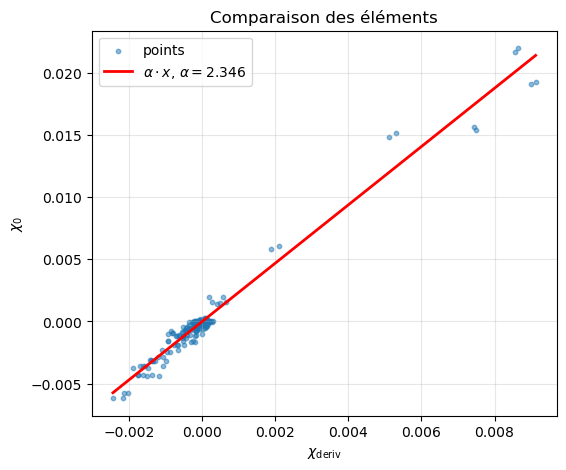

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Masque pour filtrer les valeurs
mask = (chi_matrix_0 > -0.5) & (chi_matrix_0 < 2.2)

x = chi_from_derivative[mask].copy()
y = chi_matrix_0[mask].copy()

# Régression sans biais : y ≈ a * x
factor_estimate = np.sum(x * y) / np.sum(x * x)

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(x, y, alpha=0.5, s=10, label="points")
plt.plot(np.sort(x), factor_estimate * np.sort(x),
         color="red", lw=2, label=fr"$\alpha \cdot x$, $\alpha={factor_estimate:.3f}$")

plt.xlabel(r"$\chi_{\text{deriv}}$")
plt.ylabel(r"$\chi_0$")
plt.title("Comparaison des éléments")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


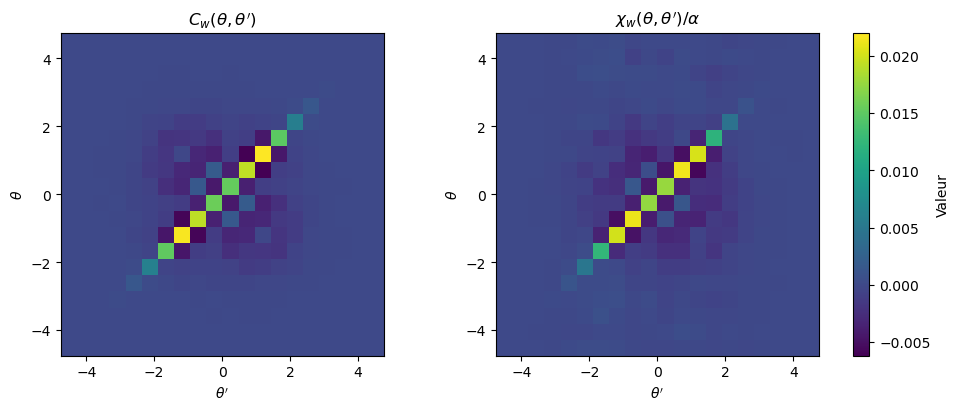

In [63]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

vmin = min(chi_matrix_0.min(), chi_from_derivative.min()*factor_estimate)
vmax = max(chi_matrix_0.max(), chi_from_derivative.max()*factor_estimate)

# Heatmap 1 : C_w(θ,θ')
im1 = axs[0].imshow(chi_matrix_0,
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    vmin=vmin, vmax=vmax,
                    origin="lower", aspect="equal")
axs[0].set_title(r"$C_w(\theta,\theta')$")
axs[0].set_xlabel(r"$\theta'$")
axs[0].set_ylabel(r"$\theta$")

# Heatmap 2 : χ_w(θ,θ')
im2 = axs[1].imshow(chi_from_derivative*factor_estimate,
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    vmin=vmin, vmax=vmax,
                    origin="lower", aspect="equal")
axs[1].set_title(r"$\chi_w(\theta,\theta')/\alpha$")
axs[1].set_xlabel(r"$\theta'$")
axs[1].set_ylabel(r"$\theta$")

# Colorbar commune
cbar = fig.colorbar(im1, ax=axs, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label(r"Valeur")

# Sauvegarde de la figure
#plt.savefig("heatmaps_10000.png", dpi=300, bbox_inches="tight")  # format PNG, 300 dpi
# plt.savefig("heatmaps.pdf", dpi=300, bbox_inches="tight")  # ou format PDF


plt.show()


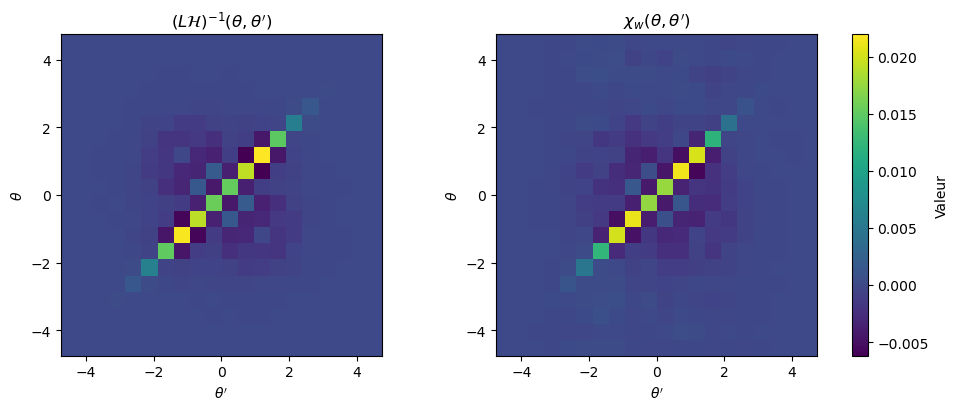

In [65]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

vmin = min(chi_matrix_0.min(), chi_from_derivative.min()*factor_estimate)
vmax = max(chi_matrix_0.max(), chi_from_derivative.max()*factor_estimate)

# Heatmap 1 : C_w(θ,θ')
im1 = axs[0].imshow(chi_matrix_0,
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    vmin=vmin, vmax=vmax,
                    origin="lower", aspect="equal")
axs[0].set_title(r"$(L \mathcal{H})^{-1}(\theta,\theta')$")
axs[0].set_xlabel(r"$\theta'$")
axs[0].set_ylabel(r"$\theta$")

# Heatmap 2 : χ_w(θ,θ')
im2 = axs[1].imshow(chi_from_derivative*factor_estimate,
                    extent=[theta_centers.min(), theta_centers.max(),
                            theta_centers.min(), theta_centers.max()],
                    vmin=vmin, vmax=vmax,
                    origin="lower", aspect="equal")
axs[1].set_title(r"$\chi_w(\theta,\theta')$")
axs[1].set_xlabel(r"$\theta'$")
axs[1].set_ylabel(r"$\theta$")

# Colorbar commune
cbar = fig.colorbar(im1, ax=axs, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label(r"Valeur")

# Sauvegarde de la figure
#plt.savefig("heatmaps_2000.png", dpi=300, bbox_inches="tight")  # format PNG, 300 dpi
# plt.savefig("heatmaps.pdf", dpi=300, bbox_inches="tight")  # ou format PDF


plt.show()


In [67]:
import numpy as np

def norme(x, p):
    """
    Calcule la norme p de x.

    - x : scalaire, vecteur (1D array) ou matrice (2D array)
    - p : 0, 1, 2, ..., np.inf

    Retourne la norme correspondante.
    """
    x = np.asarray(x)

    # Scalaire
    if x.ndim == 0:
        if p == np.inf:
            return np.abs(x)
        else:
            return np.abs(x)**p

    # Vecteur
    elif x.ndim == 1:
        if p == 0:
            return np.count_nonzero(x)
        elif p == np.inf:
            return np.max(np.abs(x))
        else:
            return np.sum(np.abs(x)**p)**(1/p)

    # Matrice
    elif x.ndim == 2:
        if p == 0:
            return np.count_nonzero(x)
        elif p == 1:
            # norme induite 1 (max colonne)
            return np.max(np.sum(np.abs(x), axis=0))
        elif p == 2:
            # norme de Frobenius
            return np.linalg.norm(x, 'fro')
        elif p == np.inf:
            # norme induite inf (max ligne)
            return np.max(np.sum(np.abs(x), axis=1))
        else:
            # norme p-matrice "élément par élément"
            return np.sum(np.abs(x)**p)**(1/p)
    else:
        raise ValueError("x doit être un scalaire, vecteur 1D ou matrice 2D")

p= 2 
print(norme(chi_matrix_0 - factor_estimate*chi_from_derivative, p)/norme(chi_matrix_0,p))
print(norme(chi_matrix_0 - chi_from_derivative, p)/norme(chi_matrix_0,p))

0.16127760285814305
0.5888321619828759


In [69]:
6*20/60

2.0

In [71]:
1583.419656/60

26.3903276

In [73]:
1/factor_estimate

0.4261729258405564